# Practice Session 08: Communities

Author: <font color="blue">Javier Algarra Pérez</font>

E-mail: <font color="blue">jalgarra@estudiant.upf.edu</font>

Date: <font color="blue">7/11/2025</font>

In [47]:
# LEAVE AS-IS

import io
import networkx as nx
import matplotlib.pyplot as plt
import random
import numpy as np
import statistics

# 1. The graph

The following code just loads the graph into variable *g*. Leave as-is.

In [48]:
# LEAVE AS-IS

INPUT_GRAPH_FILENAME = "data/starwars/starwars.graphml"

# Read the graph in GraphML format
sw_in = nx.read_graphml(INPUT_GRAPH_FILENAME)

# Re-label the nodes so they use the 'name' as label
sw_relabeled = nx.relabel.relabel_nodes(sw_in, dict(sw_in.nodes(data='name')))

# Convert the graph to undirected
sw = sw_relabeled.to_undirected()

The following code, which you can leave as-is or modify for better visualization, displays a graph. It also accepts a ``partition`` argument, which we will use later on.

In [49]:
# LEAVE AS-IS (OR MODIFY VISUALLY)

def plot_graph(g, width=20, height=20, font_size=12, partition=None):

    # Create a plot of width x height
    plt.figure(figsize=(width, height))

    # By default the partition is going to be all nodes in the same partition
    if partition is None:
        partition = [ set(g.nodes()) ]

    # Number of partitions
    num_parts = len(partition)

    # Create a map from nodes to color using color values from 0.0 for the first partition
    # to 1-1/P for the last partition, assuming there are P partitions
    node_to_color = {}
    part_color = 0.0
    for part in partition:
        for node in part:
            node_to_color[node] = part_color
        part_color += 1.0/num_parts

    # Create a list of colors in the ordering of the nodes
    colors = [node_to_color[node] for node in g.nodes()]

    # Layout the nodes using a spring model
    nx.draw_spring(g, with_labels=True, node_size=1000, font_size=font_size,
                   cmap=plt.get_cmap('YlOrRd'), node_color=colors)

    # Display
    plt.show()

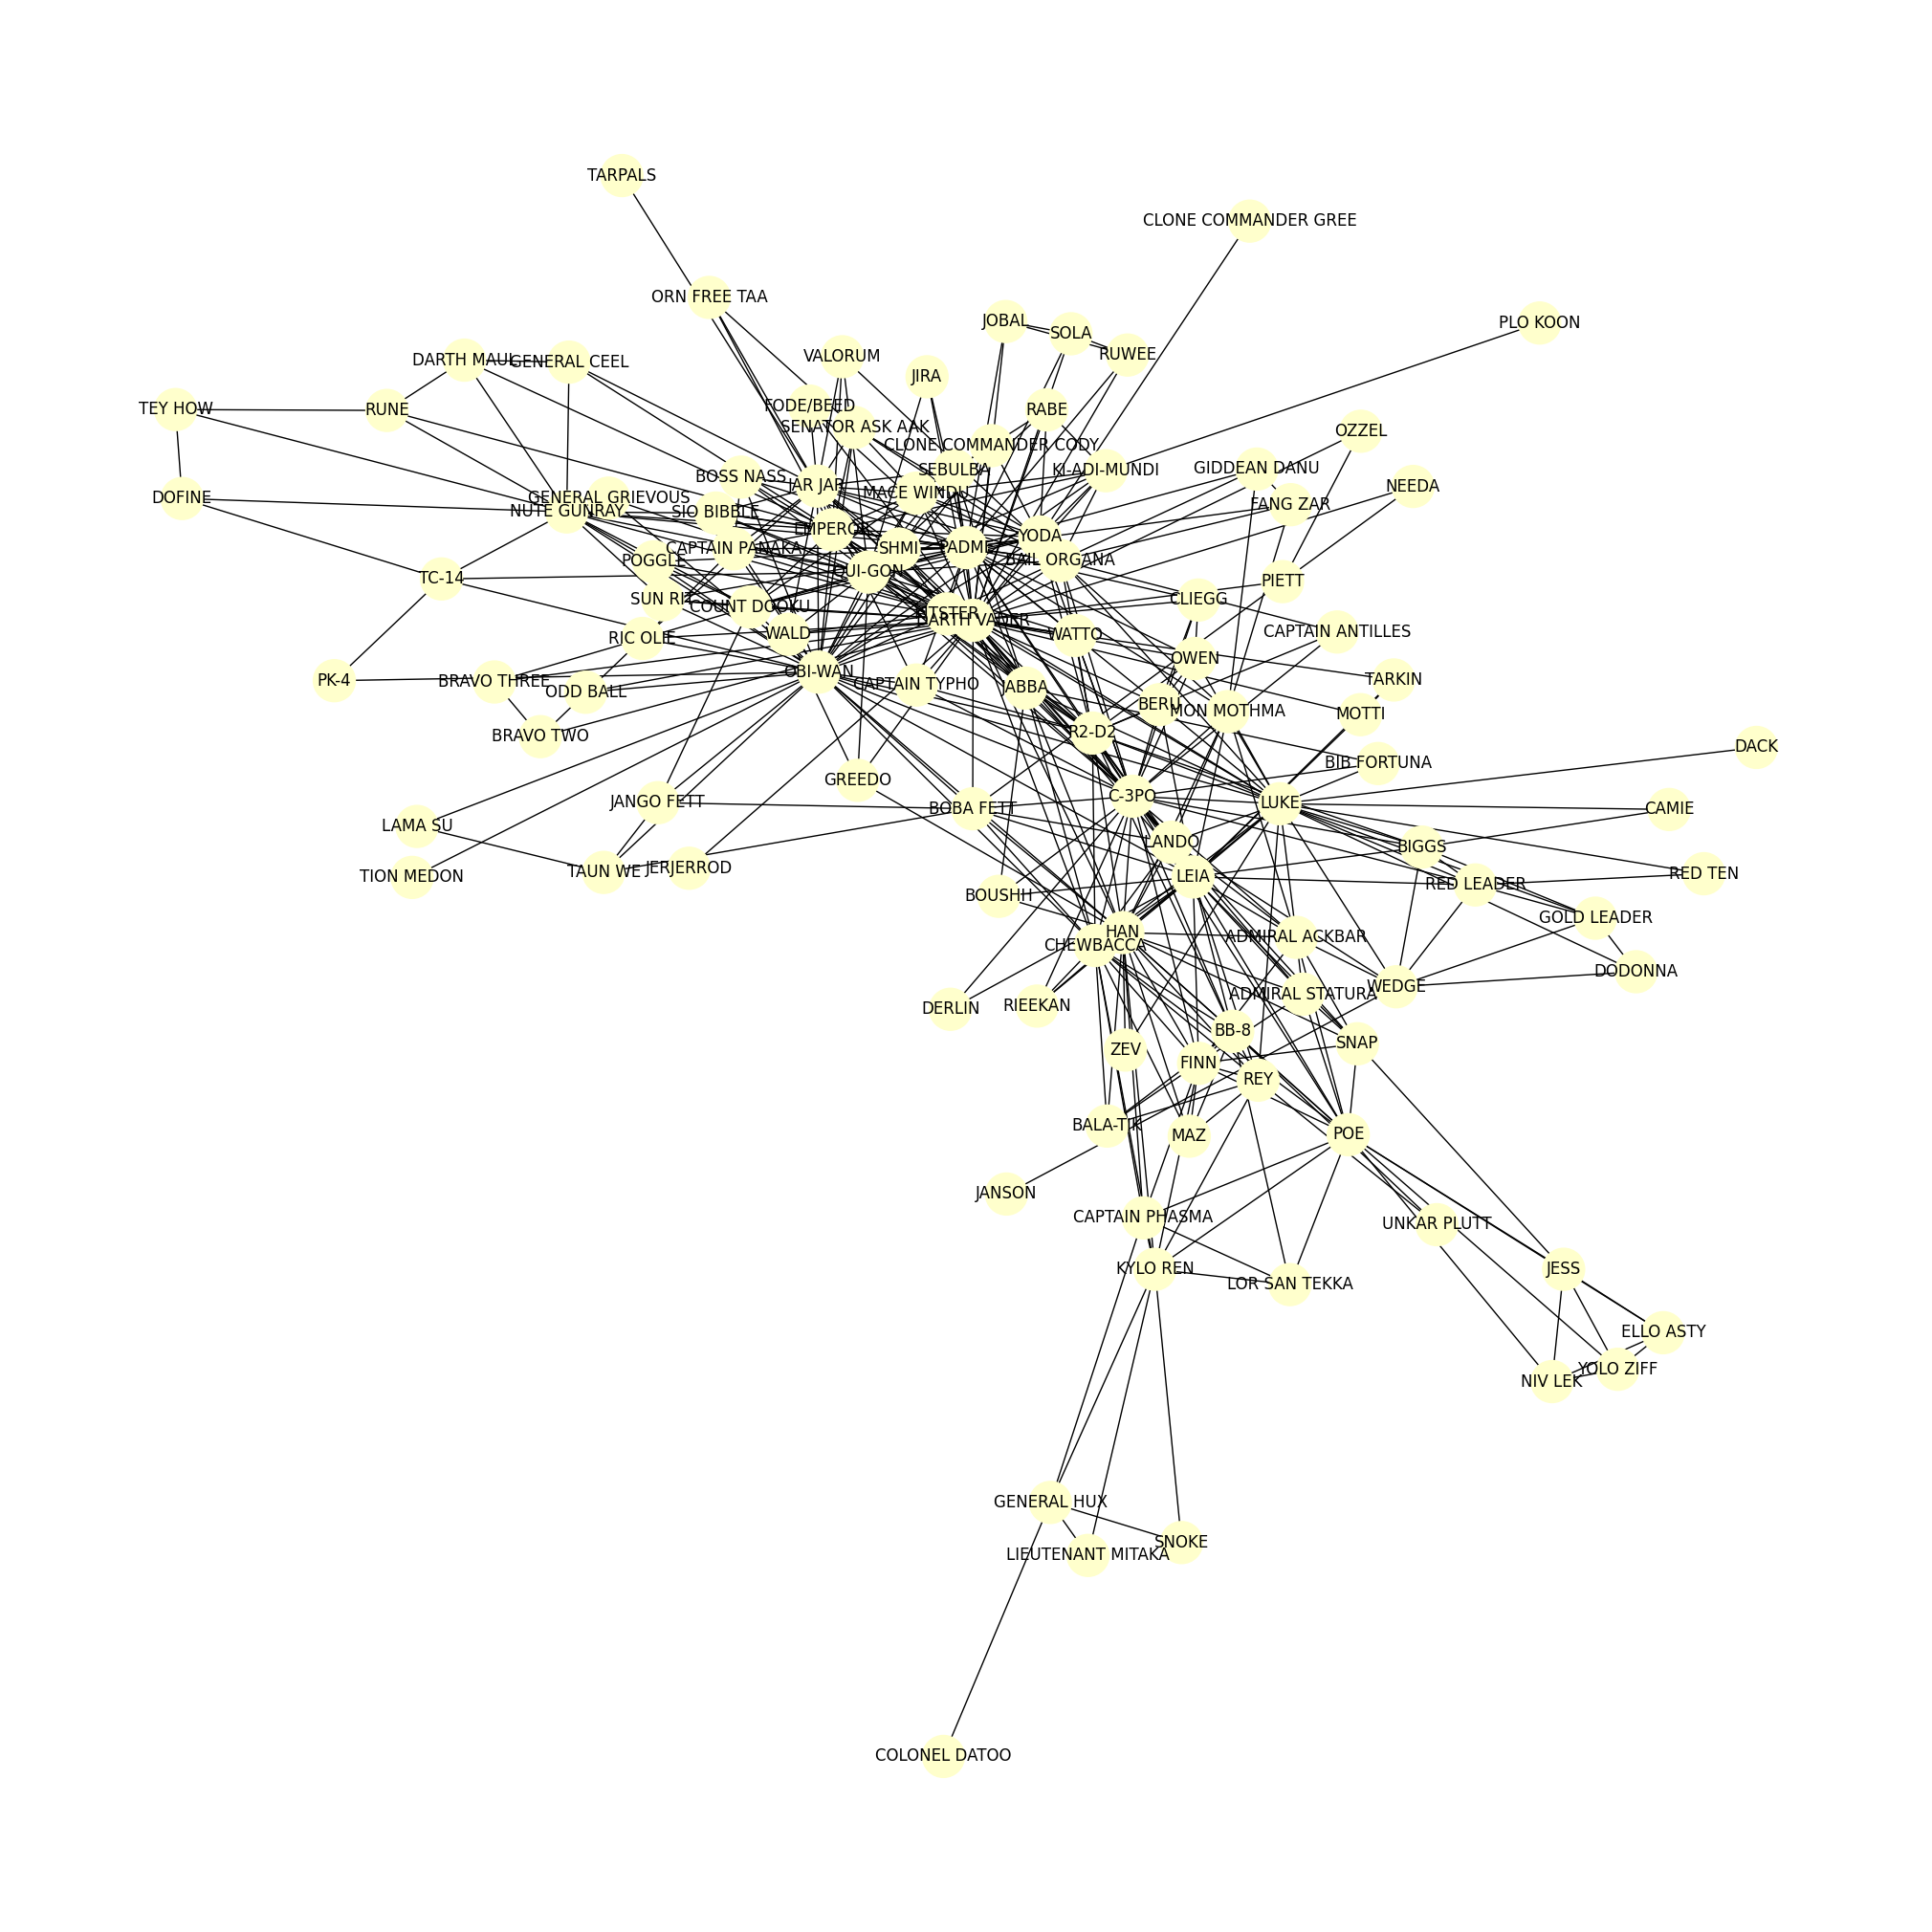

In [50]:
# LEAVE AS-IS

plot_graph(sw)

# 2. K-core decomposition

Now we will perform a k-core decomposition, using the following auxiliary functions, which you can leave as-is.

In [51]:
# LEAVE AS-IS

def get_max_degree(g):
    degree_sequence = [x[1] for x in g.degree()]
    return(max(degree_sequence))


def nodes_with_degree_less_or_equal_than(g, degree):
    nodes = []
    for node in g.nodes():
        if g.degree(node) <= degree:
            nodes.append(node)
    return nodes

Create the function `kcore_decomposition(g)`.

This function must assign the corresponding k-core to each node. It must return a dictionary node_to_kcore_number where each key is the name of the node and their value is the corresponding kcore_number.  


Start with k = 1.
    Find all nodes whose current degree is ≤ k. Here you can use the function `node_to_kcore = kcore_decomposition(g)`.  
    While such nodes exist:   
    -assign these nodes the k-core number k.  
    -remove them from the graph.  
    -recompute the degrees and find again all nodes with degree ≤ k.  
    When no more nodes of degree ≤ k remain, increase k by 1.   
Repeat until k reaches the maximum degree or the graph is empty.  

In [52]:
def kcore_decomposition(g):
    G = g.copy()
    
    node_to_kcore_number = {}
    
    k = 1
    
    while G.number_of_nodes() > 0:
        nodes_to_remove = [node for node, deg in G.degree() if deg <= k]
        
        if nodes_to_remove:
            for node in nodes_to_remove:
                node_to_kcore_number[node] = k
            G.remove_nodes_from(nodes_to_remove)
        else:
            k += 1
            
    return node_to_kcore_number


In [53]:
# LEAVE AS-IS

node_to_kcore = kcore_decomposition(sw)

for character in ["LEIA", "C-3PO", "REY", "TARKIN"]:
    print("K-core of {:s}: {:d}".format(character, node_to_kcore[character]))

K-core of LEIA: 7
K-core of C-3PO: 8
K-core of REY: 6
K-core of TARKIN: 3


Now, create a function to create a k-core subraph as a function of k. You can use [Graph.subgraph](https://networkx.org/documentation/stable/reference/classes/generated/networkx.Graph.subgraph.html). Execute the function to create and draw k-core subgraph `swcore`, containing only the nodes with k-core number greater or equal to **4**.

In [54]:
def create_kcores_subgraph(g, k):
    g_copy = g.copy()
    node_to_kcore = kcore_decomposition(g)
    nodes_to_remove = []
    for node in g.nodes():
        if node_to_kcore[node] < k:
            nodes_to_remove.append(node)
    g_copy.remove_nodes_from(nodes_to_remove)
    return g_copy

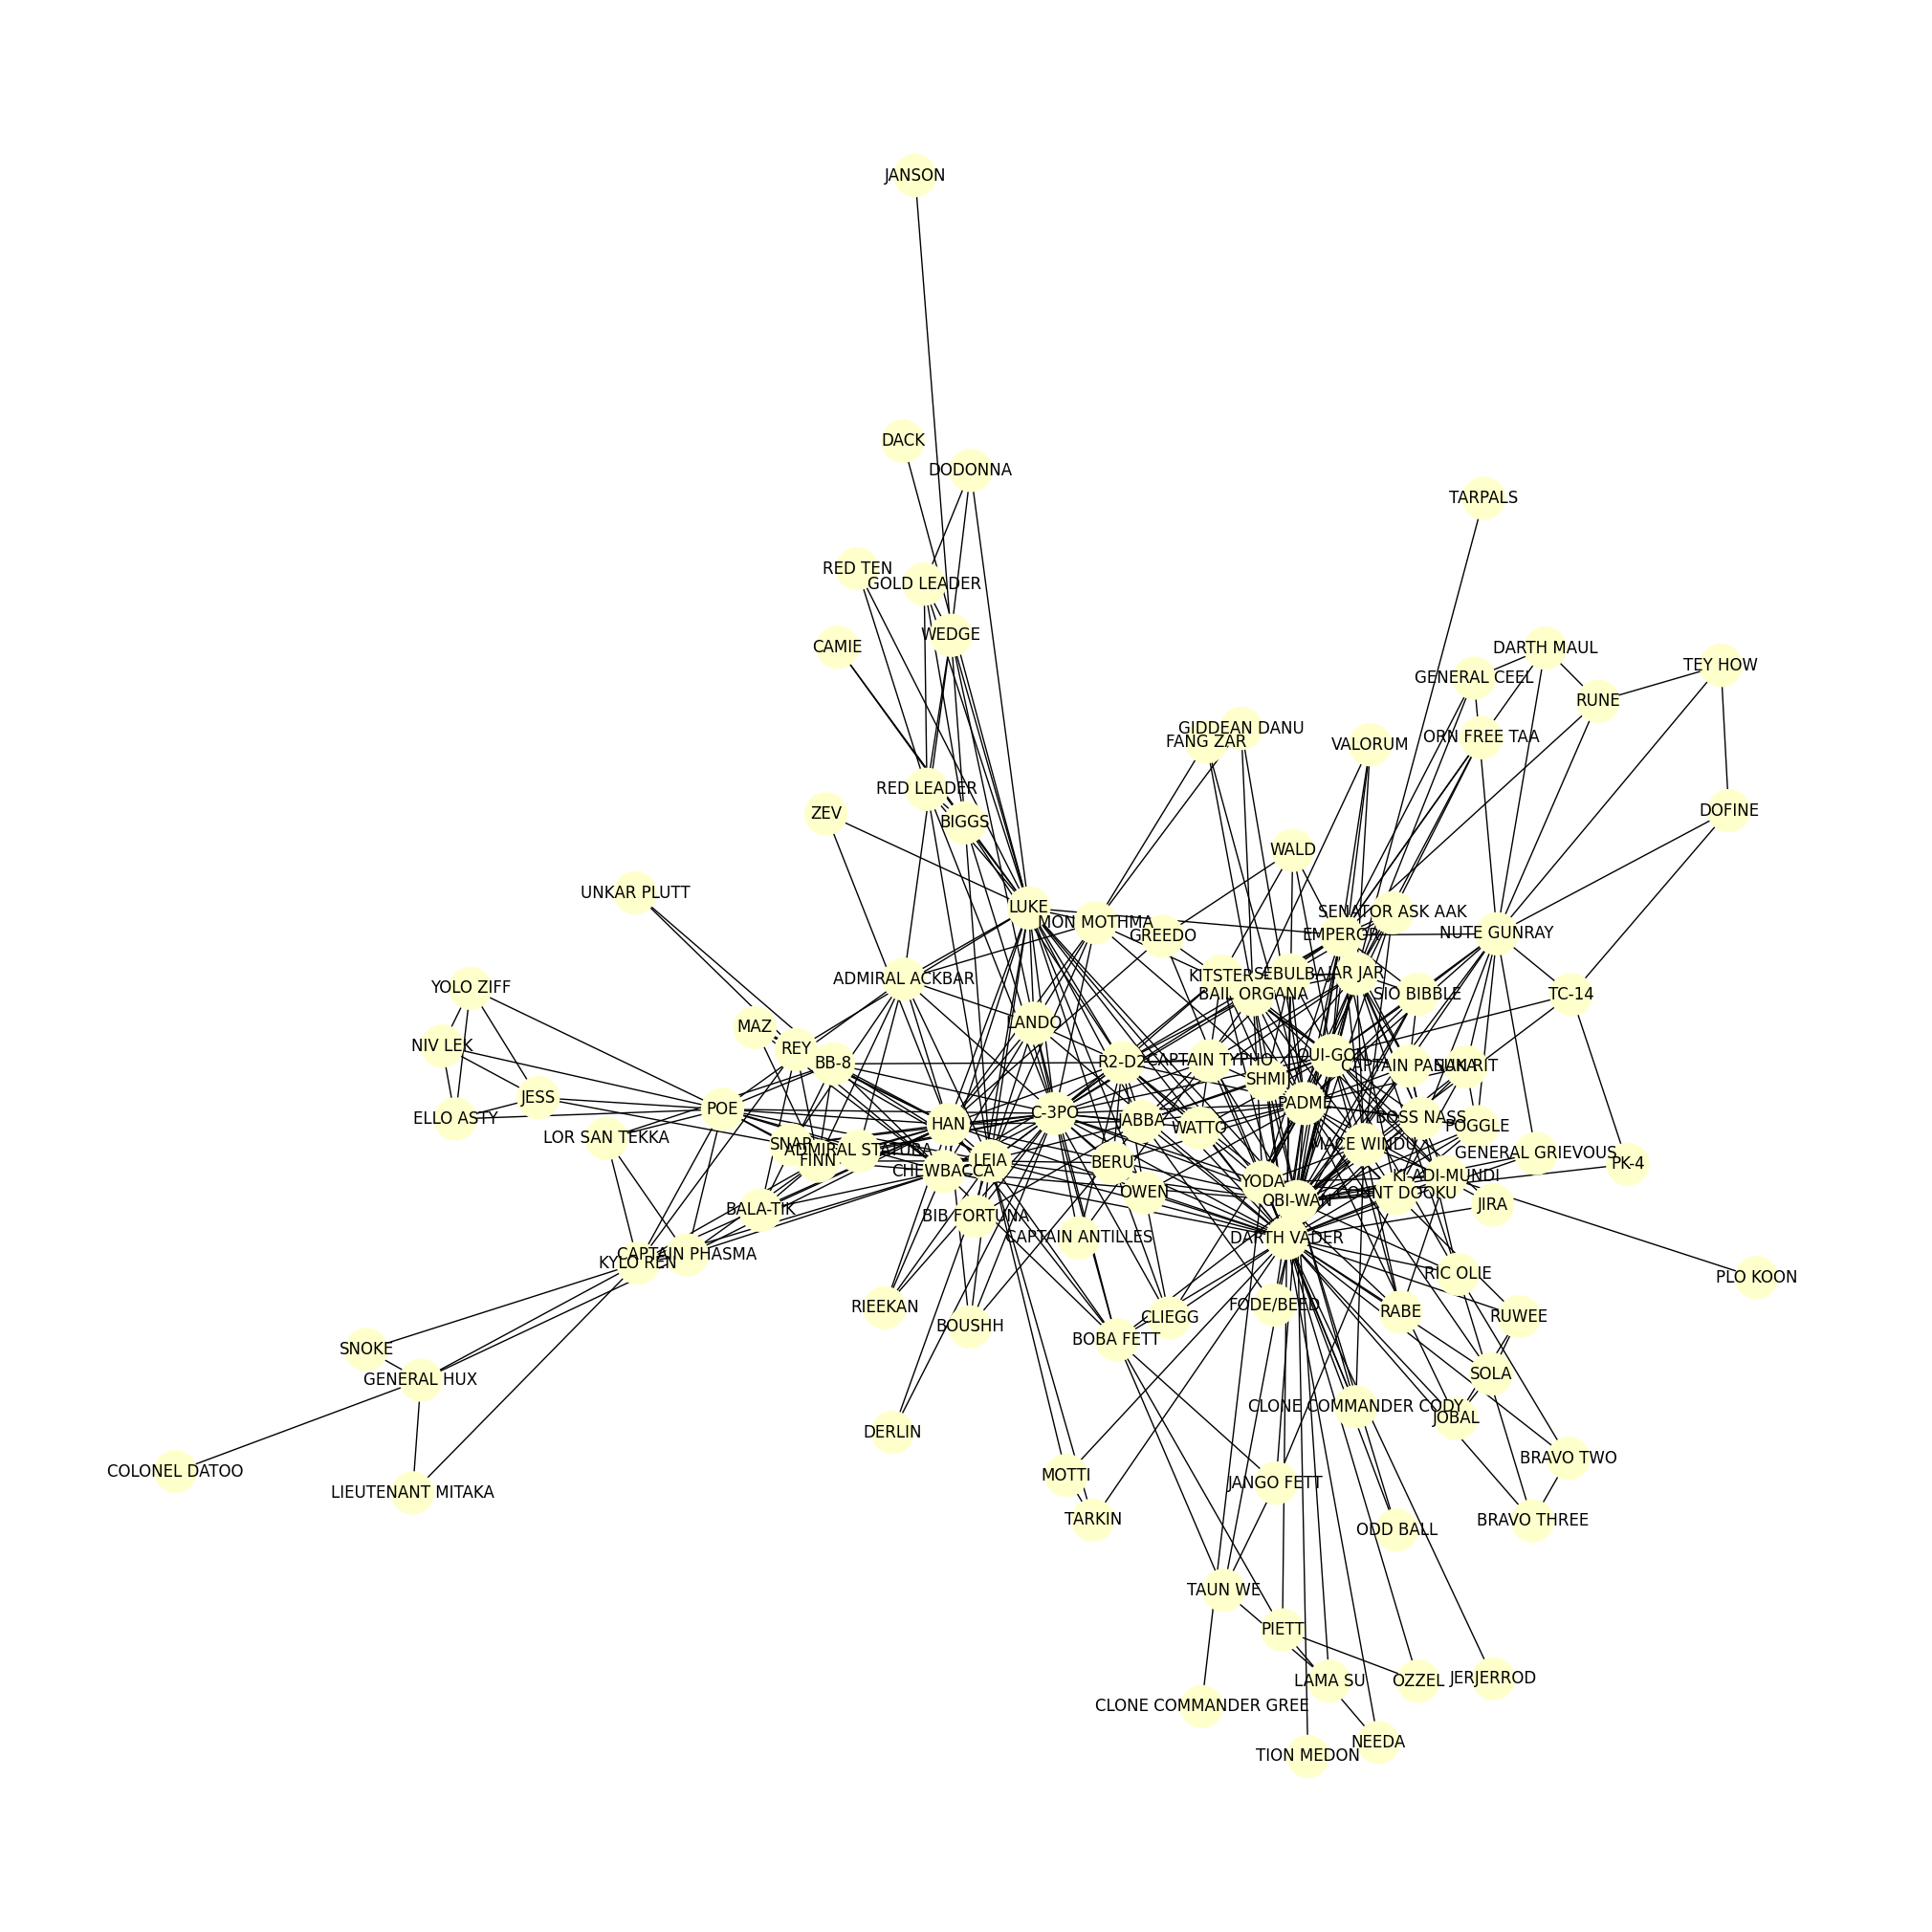

In [55]:
k = 4
swcore = create_kcores_subgraph(sw, k)  
plot_graph(sw)


We will compute the modularity of a partitioning. First, let's draw a small toy graph.

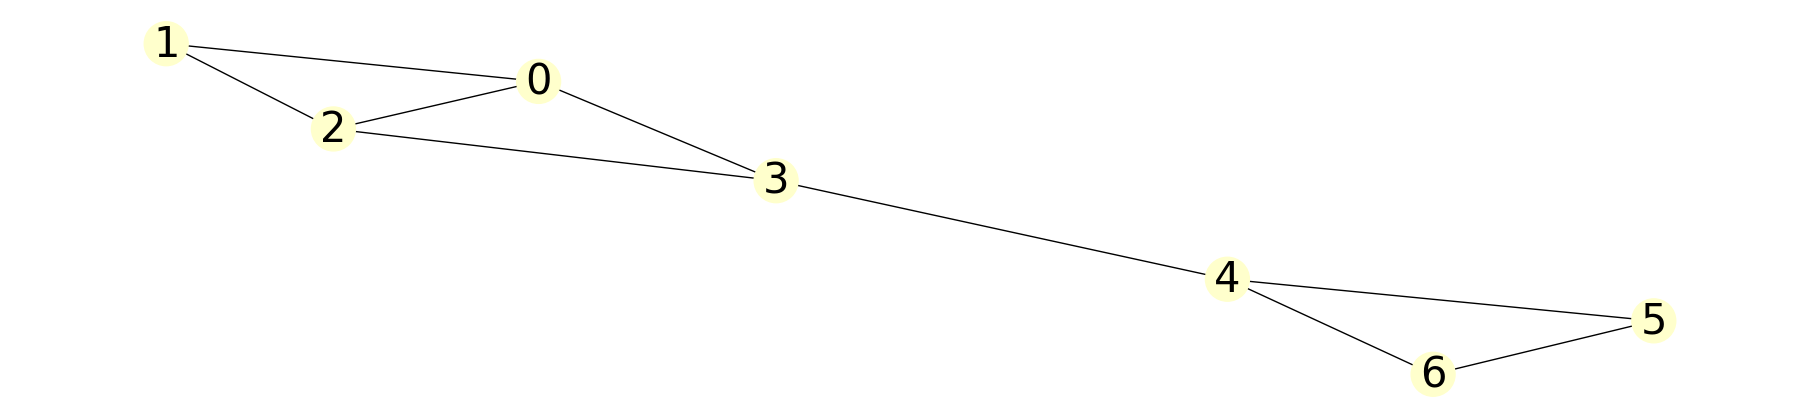

In [56]:
# Leave as-is

g = nx.Graph()

g.add_edge(0, 1)
g.add_edge(1, 2)
g.add_edge(2, 3)
g.add_edge(3, 0)
g.add_edge(0, 2)
g.add_edge(3, 4)
g.add_edge(4, 5)
g.add_edge(5, 6)
g.add_edge(6, 4)

# NOTE: for each run, the visualization will be different, but the graph should have the connections indicated above
plot_graph(g, height=4, width=18, font_size=30)

A partition of a graph is represented as a list of sets. Each set represents a part of the graph. For instance, the following are two partitions. The first one is arguably the most natural way of dividing this graph: nodes 0, 1, 2, 3 belong to one partition, and nodes 4, 5, and 6 to the other partition. The second one places the node 3 in the "wrong" partition.

NetworkX has a function to compute the modularity of a partition: [community.quality.modularity](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.quality.modularity.html). It applies the formula we discussed in class:

$$
Q = \frac{1}{L} \sum_{C} \left( L_C - \frac{k_C^2}{4L} \right)
$$

Where:

* Q is the modularity
* C is a community
* L<sub>C</sub> is the number of internal links in C (internal means connecting two nodes in C)
* K<sub>C</sub> is the summation of the degree of nodes in C
* L is the total number of links in the graph

Remember that in modularity, the greater it is the better partitioned it is.


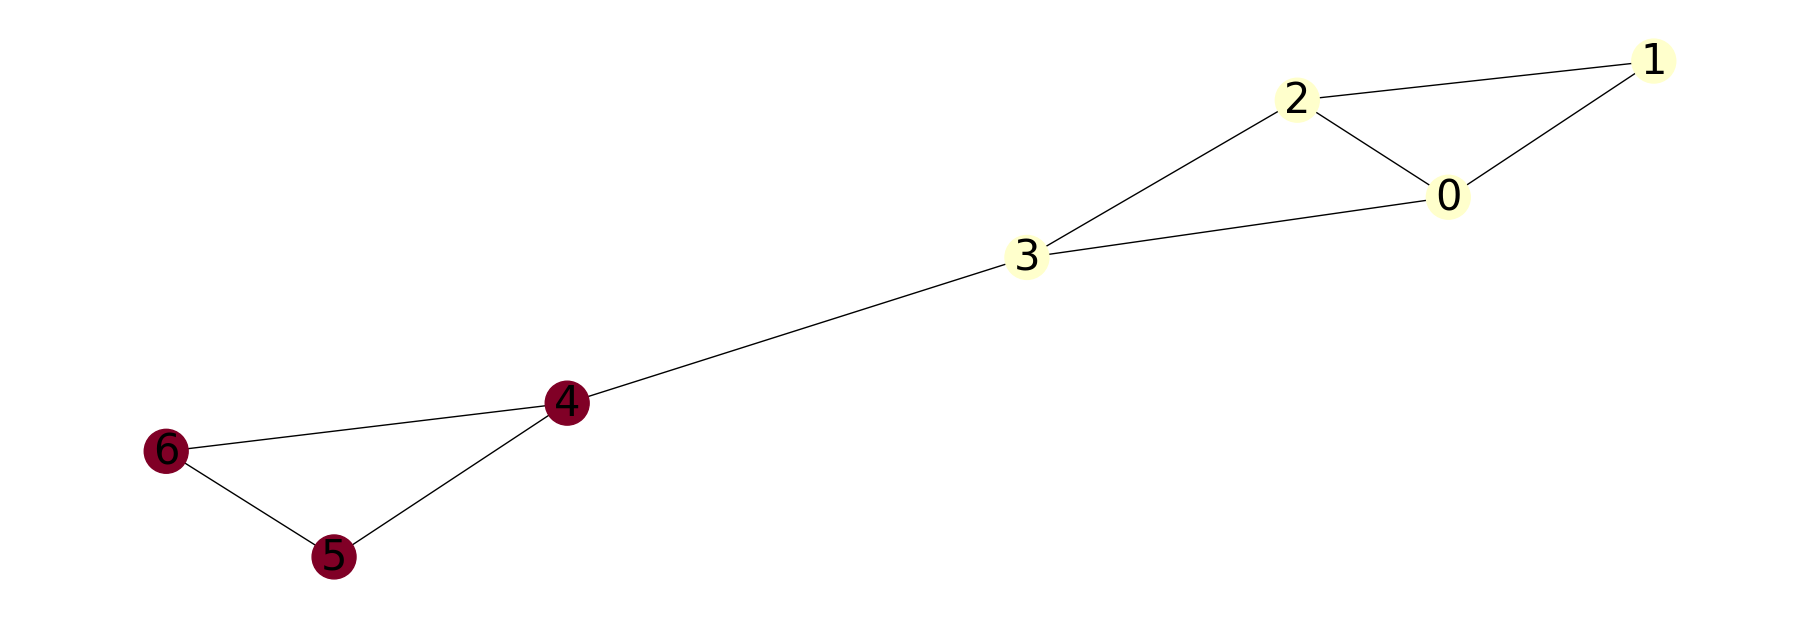

Modularity of partition 1 according to NetworkX: 0.3642


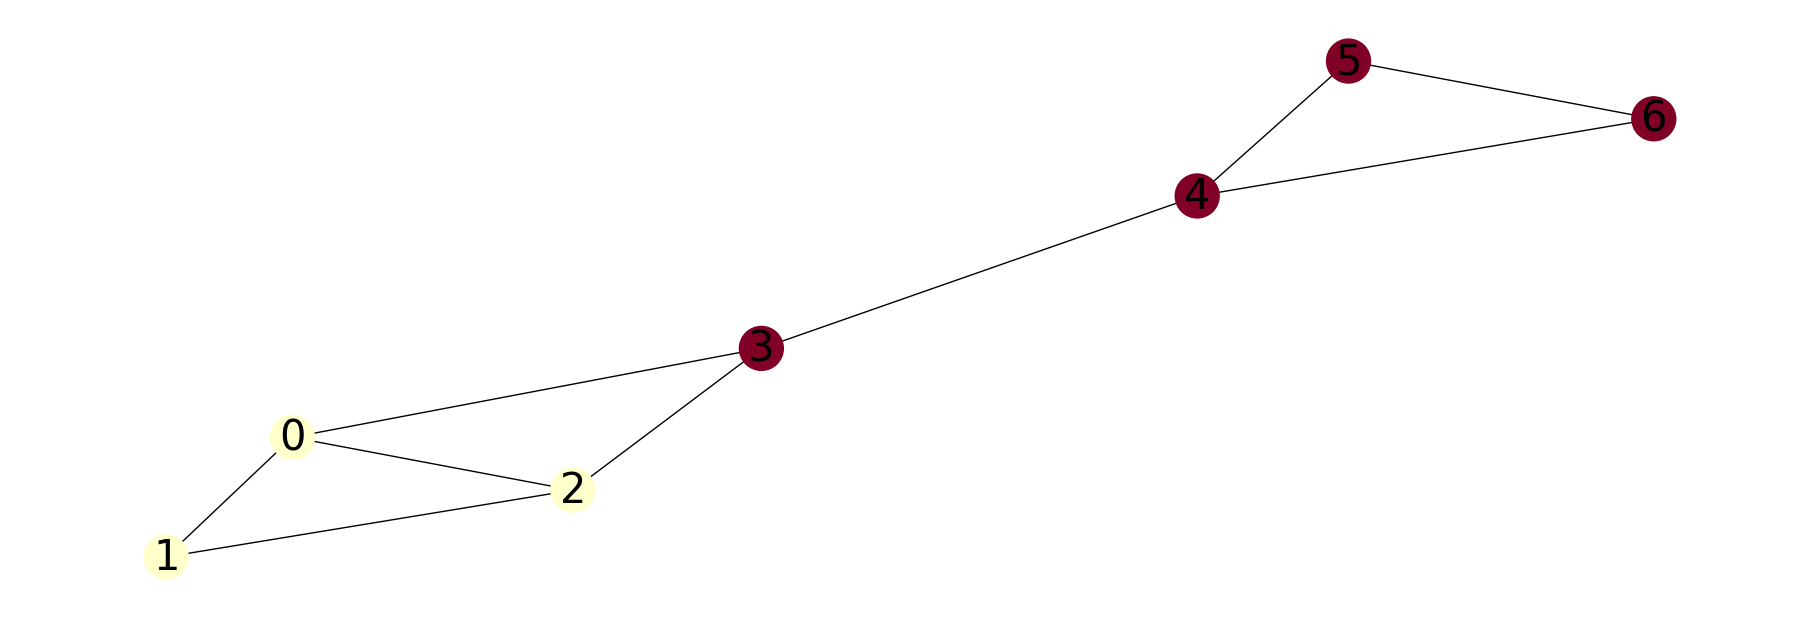

Modularity of partition 2 according to NetworkX: 0.2716


In [57]:
# LEAVE AS-IS

partition1 = [
    {0, 1, 2, 3},
    {4, 5, 6}
]
plot_graph(g, height=6, width=18, font_size=30, partition=partition1)
print("Modularity of partition 1 according to NetworkX: %.4f" % nx.community.quality.modularity(g, partition1))


partition2 = [
    {0, 1, 2},
    {3, 4, 5, 6}
]
plot_graph(g, height=6, width=18, font_size=30, partition=partition2)
print("Modularity of partition 2 according to NetworkX: %.4f" % nx.community.quality.modularity(g, partition2))

Create a function `modularity(g, partition)`. First, define two auxiliary functions:

* `Lc(g, C)`, returning the number of internal links within community C. An easy way of doing this is creating a [subgraph](https://networkx.org/documentation/stable/reference/classes/generated/networkx.Graph.subgraph.html) of g restricted to the nodes in C, and then counting the [number of edges](https://networkx.org/documentation/stable/reference/classes/generated/networkx.Graph.number_of_edges.html) in that subgraph.
* `kc(g, C)`, returning the sumation of the degree of nodes in C in the graph g (do not create a subgraph).

Then, write the function `modularity: def modularity(g, partition)` using these two auxiliary functions. Remember to use the formula defined in theory.

In [58]:
def Lc(g, C):
    glc = g.subgraph(C)
    return glc.number_of_edges()

def kc(g, C):
    total_degree = 0
    for node in C:
        total_degree += g.degree(node)
    return total_degree

def modularity(g, partition):
    L = g.number_of_edges()
    total = 0
    for i in range(len(partition)):
        lci = Lc(g, partition[i])
        kci = kc(g, partition[i])
        total += lci - (kci**2) / (4 * L)
    total_m = total / L
    return total_m

Use the following to test your code.

In [59]:
# LEAVE AS-IS

print("Modularity of partition 1: mine={:.6f}, networkx={:.6f}".format(
    modularity(g, partition1), nx.community.quality.modularity(g, partition1)))

print("Modularity of partition 2: mine={:.6f}, networkx={:.6f}".format(
    modularity(g, partition2), nx.community.quality.modularity(g, partition2)))


Modularity of partition 1: mine=0.364198, networkx=0.364198
Modularity of partition 2: mine=0.271605, networkx=0.271605


# 4. Girvan-Newman algorithm

The Girvan-Newman algorithm generates a series of partitions of a graph. The first has simply the entire graph in one partition, and the last has one partition per node.

The way in which the algorithm operates is by iteratively removing the edge with the largest edge betweenness, and returning a new partition every time the number of connected components of the graph increases.

Now, write a function to find the edge with the largest betweenness in a graph.

First, use function [edge_betweenness_centrality](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.centrality.edge_betweenness_centrality.html) to obtain a dictionary in which keys are edges, and values are edge betweenness.

Then, iterate through those keys and find the one with the maximum edge betweenness. Return that key.

*Tip:* the dictionary returned by ``edge_betweenness_centrality`` sometimes has triples *(u,v,0)* as keys, instead of simple tuples *(u,v)*. In that case, remember to return simply *(u,v)*. You can check how many values a tuple *t* contains by using ``len(t)``.


In [60]:
def largest_betweenness_edge(g):
    betweenness = nx.edge_betweenness_centrality(g)
    max_edge = None
    max_betweenness = -1

    for edge, value in betweenness.items():
        if value > max_betweenness:
            max_betweenness = value
            max_edge = edge

    # edge puede ser (u, v) o (u, v, 0)
    if len(max_edge) == 3:
        return (max_edge[0], max_edge[1])
    else:
        return max_edge


We will use the following auxiliary function, that you can leave as-is. The reason we are introducing function `list_connected_components` is convenience, as the function [connected_components](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.components.connected_components.html) in NetworkX returns a [generator](https://wiki.python.org/moin/Generators) instead of a list.

In [61]:
# LEAVE AS-IS

def list_connected_components(g):
    return list(nx.connected_components(g))

def number_connected_components(g):
    return len(list_connected_components(g))


Now you will implement the `girvan_newman` algorithm:

The Newman–Girvan algorithm is a method to detect communities in a network. A community is a group of nodes that are more densely connected to each other than to the rest of the network. The algorithm identifies communities by removing edges that are “between” communities. The idea is that edges connecting different communities are more “important” in holding the network together, while edges inside a community are less critical.   

Your code has to:   
    - Create a partition sequence.  
    - Include the whole graph as the first partition.  
    - Iteratively, while the number of connected components is smaller thant the number of nodes:   
        - Compute edge betweenness.      
        - Remove the edge with the highest betweenness.   
        - Compute the number of connected components.  
        - I the number of connected components has increased add a the new list of connected components to the sequence.   

The output should be partition sequence, i.e., a list of partitions of the graph. In this particular case, the partition sequence looks like this:

```python
[[{0, 1, 2, 3, 4, 5, 6}],
 [{0, 1, 2, 3}, {4, 5, 6}],
 [{0, 2, 3}, {1}, {4, 5, 6}],
 ...
 [{0}, {1}, {2}, {3}, {4}, {5}, {6}]]
```

The way to interpret this is as follows:

* The first partition is simply all nodes in a single part
* The second partition happens after removing edge (3, 4), and divides the graph into two partitions
* The third partition happens after removing edges (0, 1) and (1, 2), ...
* ...
* The last partition happens after removing all edges, and each node is a singleton

In [62]:
import networkx as nx

def girvan_newman(g):
    g_work = g.copy()

    partitions = []
    # Primera partición: TODO el grafo como un solo conjunto de nodos
    partitions.append([set(g_work.nodes())])

    # Número de componentes previo (del grafo)
    prev_cc = nx.number_connected_components(g_work)

    while g_work.number_of_edges() > 0 and prev_cc < g_work.number_of_nodes():
        # Arista con mayor betweenness
        edge_to_remove = largest_betweenness_edge(g_work)

        # Eliminar arista
        g_work.remove_edge(*edge_to_remove)

        # Número de componentes actual
        curr_cc = nx.number_connected_components(g_work)

        # Si ha aumentado, añadimos la nueva partición
        if curr_cc > prev_cc:
            components = [set(c) for c in nx.connected_components(g_work)]
            partitions.append(components)
            prev_cc = curr_cc

    return partitions


In [63]:
# LEAVE AS-IS
def run_girvan_newman(g, graph_name="Graph"):

    partitions = girvan_newman(g)
    modularity_profile = []
    i = 1
    for partition in partitions:
        print("Number of partitions=" + str(i))
        print("Partition %s" % (partition,))
        m = modularity(g, partition)
        print("Modularity: %.4f" % m)
        modularity_profile.append(m)
        print()
        i += 1

    # Correct x-axis for plotting
    x = np.arange(1, len(modularity_profile) + 1)

    # Adjust point size inversely to number of points
    point_size = max(20, 200 / len(modularity_profile))

    plt.xlabel("Partition nº")
    plt.ylabel("Modularity")
    plt.title("Modularity profile")
    plt.scatter(x, modularity_profile, s=point_size, label=graph_name)
    plt.legend()


Number of partitions=1
Partition [{0, 1, 2, 3, 4, 5, 6}]
Modularity: 0.0000

Number of partitions=2
Partition [{0, 1, 2, 3}, {4, 5, 6}]
Modularity: 0.3642

Number of partitions=3
Partition [{0, 2, 3}, {1}, {4, 5, 6}]
Modularity: 0.2531

Number of partitions=4
Partition [{0}, {1}, {2, 3}, {4, 5, 6}]
Modularity: 0.1420

Number of partitions=5
Partition [{0}, {1}, {2}, {3}, {4, 5, 6}]
Modularity: 0.0864

Number of partitions=6
Partition [{0}, {1}, {2}, {3}, {4}, {5, 6}]
Modularity: -0.0617

Number of partitions=7
Partition [{0}, {1}, {2}, {3}, {4}, {5}, {6}]
Modularity: -0.1481



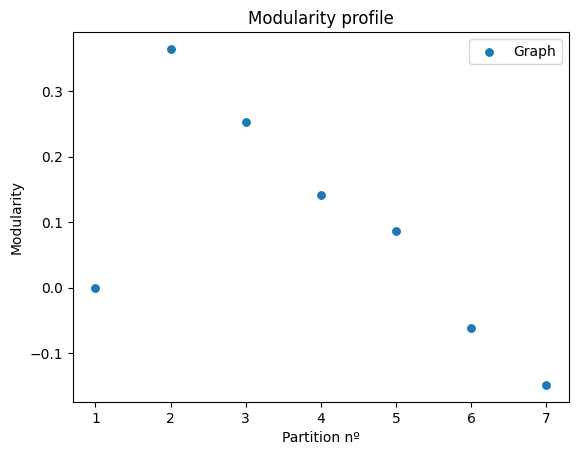

In [64]:
# LEAVE AS-IS

run_girvan_newman(g)

Number of partitions=1
Partition [{'SHMI', 'CHEWBACCA', 'NUTE GUNRAY', 'EMPEROR', 'PADME', 'BOBA FETT', 'ZEV', 'PIETT', 'CAPTAIN ANTILLES', 'BRAVO TWO', 'RUWEE', 'JANSON', 'DARTH MAUL', 'RUNE', 'DARTH VADER', 'LANDO', 'ORN FREE TAA', 'CAPTAIN PHASMA', 'DOFINE', 'OWEN', 'WEDGE', 'BERU', 'FANG ZAR', 'DERLIN', 'RABE', 'KITSTER', 'BAIL ORGANA', 'BB-8', 'SNOKE', 'TC-14', 'BIB FORTUNA', 'RIEEKAN', 'CLONE COMMANDER CODY', 'WATTO', 'ODD BALL', 'R2-D2', 'BALA-TIK', 'JOBAL', 'JESS', 'GENERAL HUX', 'LOR SAN TEKKA', 'SEBULBA', 'CLIEGG', 'TION MEDON', 'CAPTAIN PANAKA', 'MAZ', 'MACE WINDU', 'GENERAL CEEL', 'BRAVO THREE', 'POGGLE', 'GOLD LEADER', 'ELLO ASTY', 'BOUSHH', 'GIDDEAN DANU', 'NEEDA', 'ADMIRAL ACKBAR', 'JAR JAR', 'JANGO FETT', 'GENERAL GRIEVOUS', 'OBI-WAN', 'BIGGS', 'LEIA', 'LAMA SU', 'C-3PO', 'PK-4', 'FINN', 'MOTTI', 'UNKAR PLUTT', 'SOLA', 'CAMIE', 'MON MOTHMA', 'RED LEADER', 'COUNT DOOKU', 'CAPTAIN TYPHO', 'PLO KOON', 'BOSS NASS', 'DACK', 'DODONNA', 'GREEDO', 'SUN RIT', 'SIO BIBBLE', 'POE'

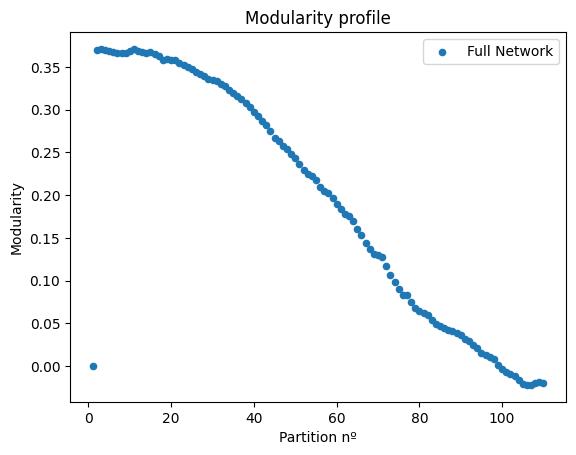

In [65]:
# LEAVE AS-IS

run_girvan_newman(sw,"Full Network")


Number of partitions=1
Partition [{'SHMI', 'CHEWBACCA', 'GOLD LEADER', 'BOSS NASS', 'ELLO ASTY', 'BOUSHH', 'NUTE GUNRAY', 'EMPEROR', 'GREEDO', 'GIDDEAN DANU', 'BOBA FETT', 'SUN RIT', 'SIO BIBBLE', 'PADME', 'RIEEKAN', 'POE', 'ADMIRAL ACKBAR', 'CLONE COMMANDER CODY', 'JAR JAR', 'YOLO ZIFF', 'WATTO', 'RUWEE', 'QUI-GON', 'ADMIRAL STATURA', 'YODA', 'R2-D2', 'JABBA', 'BALA-TIK', 'DARTH VADER', 'OBI-WAN', 'BIGGS', 'POGGLE', 'JOBAL', 'KI-ADI-MUNDI', 'WALD', 'JESS', 'LANDO', 'LEIA', 'LOR SAN TEKKA', 'C-3PO', 'LUKE', 'HAN', 'SEBULBA', 'CLIEGG', 'CAPTAIN PHASMA', 'FINN', 'OWEN', 'CAPTAIN PANAKA', 'WEDGE', 'NIV LEK', 'SOLA', 'BERU', 'FANG ZAR', 'MAZ', 'KYLO REN', 'MON MOTHMA', 'SENATOR ASK AAK', 'REY', 'MACE WINDU', 'RABE', 'KITSTER', 'RED LEADER', 'VALORUM', 'BAIL ORGANA', 'COUNT DOOKU', 'SNAP', 'BB-8', 'CAPTAIN TYPHO', 'RIC OLIE'}]
Modularity: 0.0000

Number of partitions=2
Partition [{'YOLO ZIFF', 'NIV LEK', 'JESS', 'POE', 'ELLO ASTY'}, {'CHEWBACCA', 'SHMI', 'GOLD LEADER', 'NUTE GUNRAY', 'BOUSH

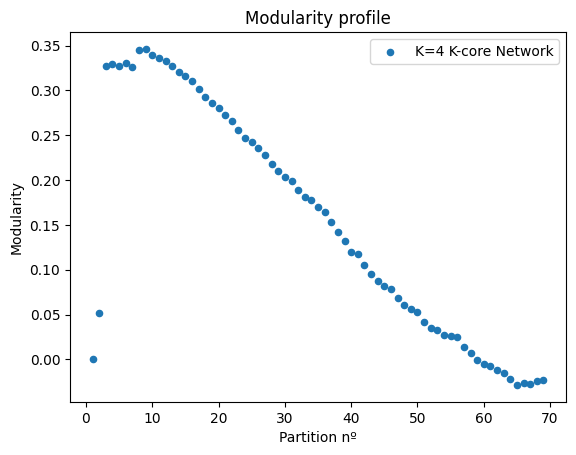

In [66]:
run_girvan_newman(swcore, "K=4 K-core Network")

<font size="+1" color="red">Replace this cell with a brief answer to these questions:  
How many partitions result in highest modularity for each graph Full Network (sw) and k=4 (swcore)?.  
In general, how does modularity evolve with the number of partitions?
</font>

In [70]:
def run_girvan_newman_modularity(graph):
    partitions = girvan_newman(graph)
    max = 0
    for partition in partitions:
        mod = modularity(graph, partition)
        if mod > max:
            max = mod
            best_partition = partition
    return best_partition

Create function `run_girvan_newman_modularity` that runs Girvan-Newman and returns the partition with the largest modularity.

The following cell, which you can leave as-is, runs this over the entire graph  and its corresponding k-core 4.

The best partition has modularity 0.3711 and 3 communities


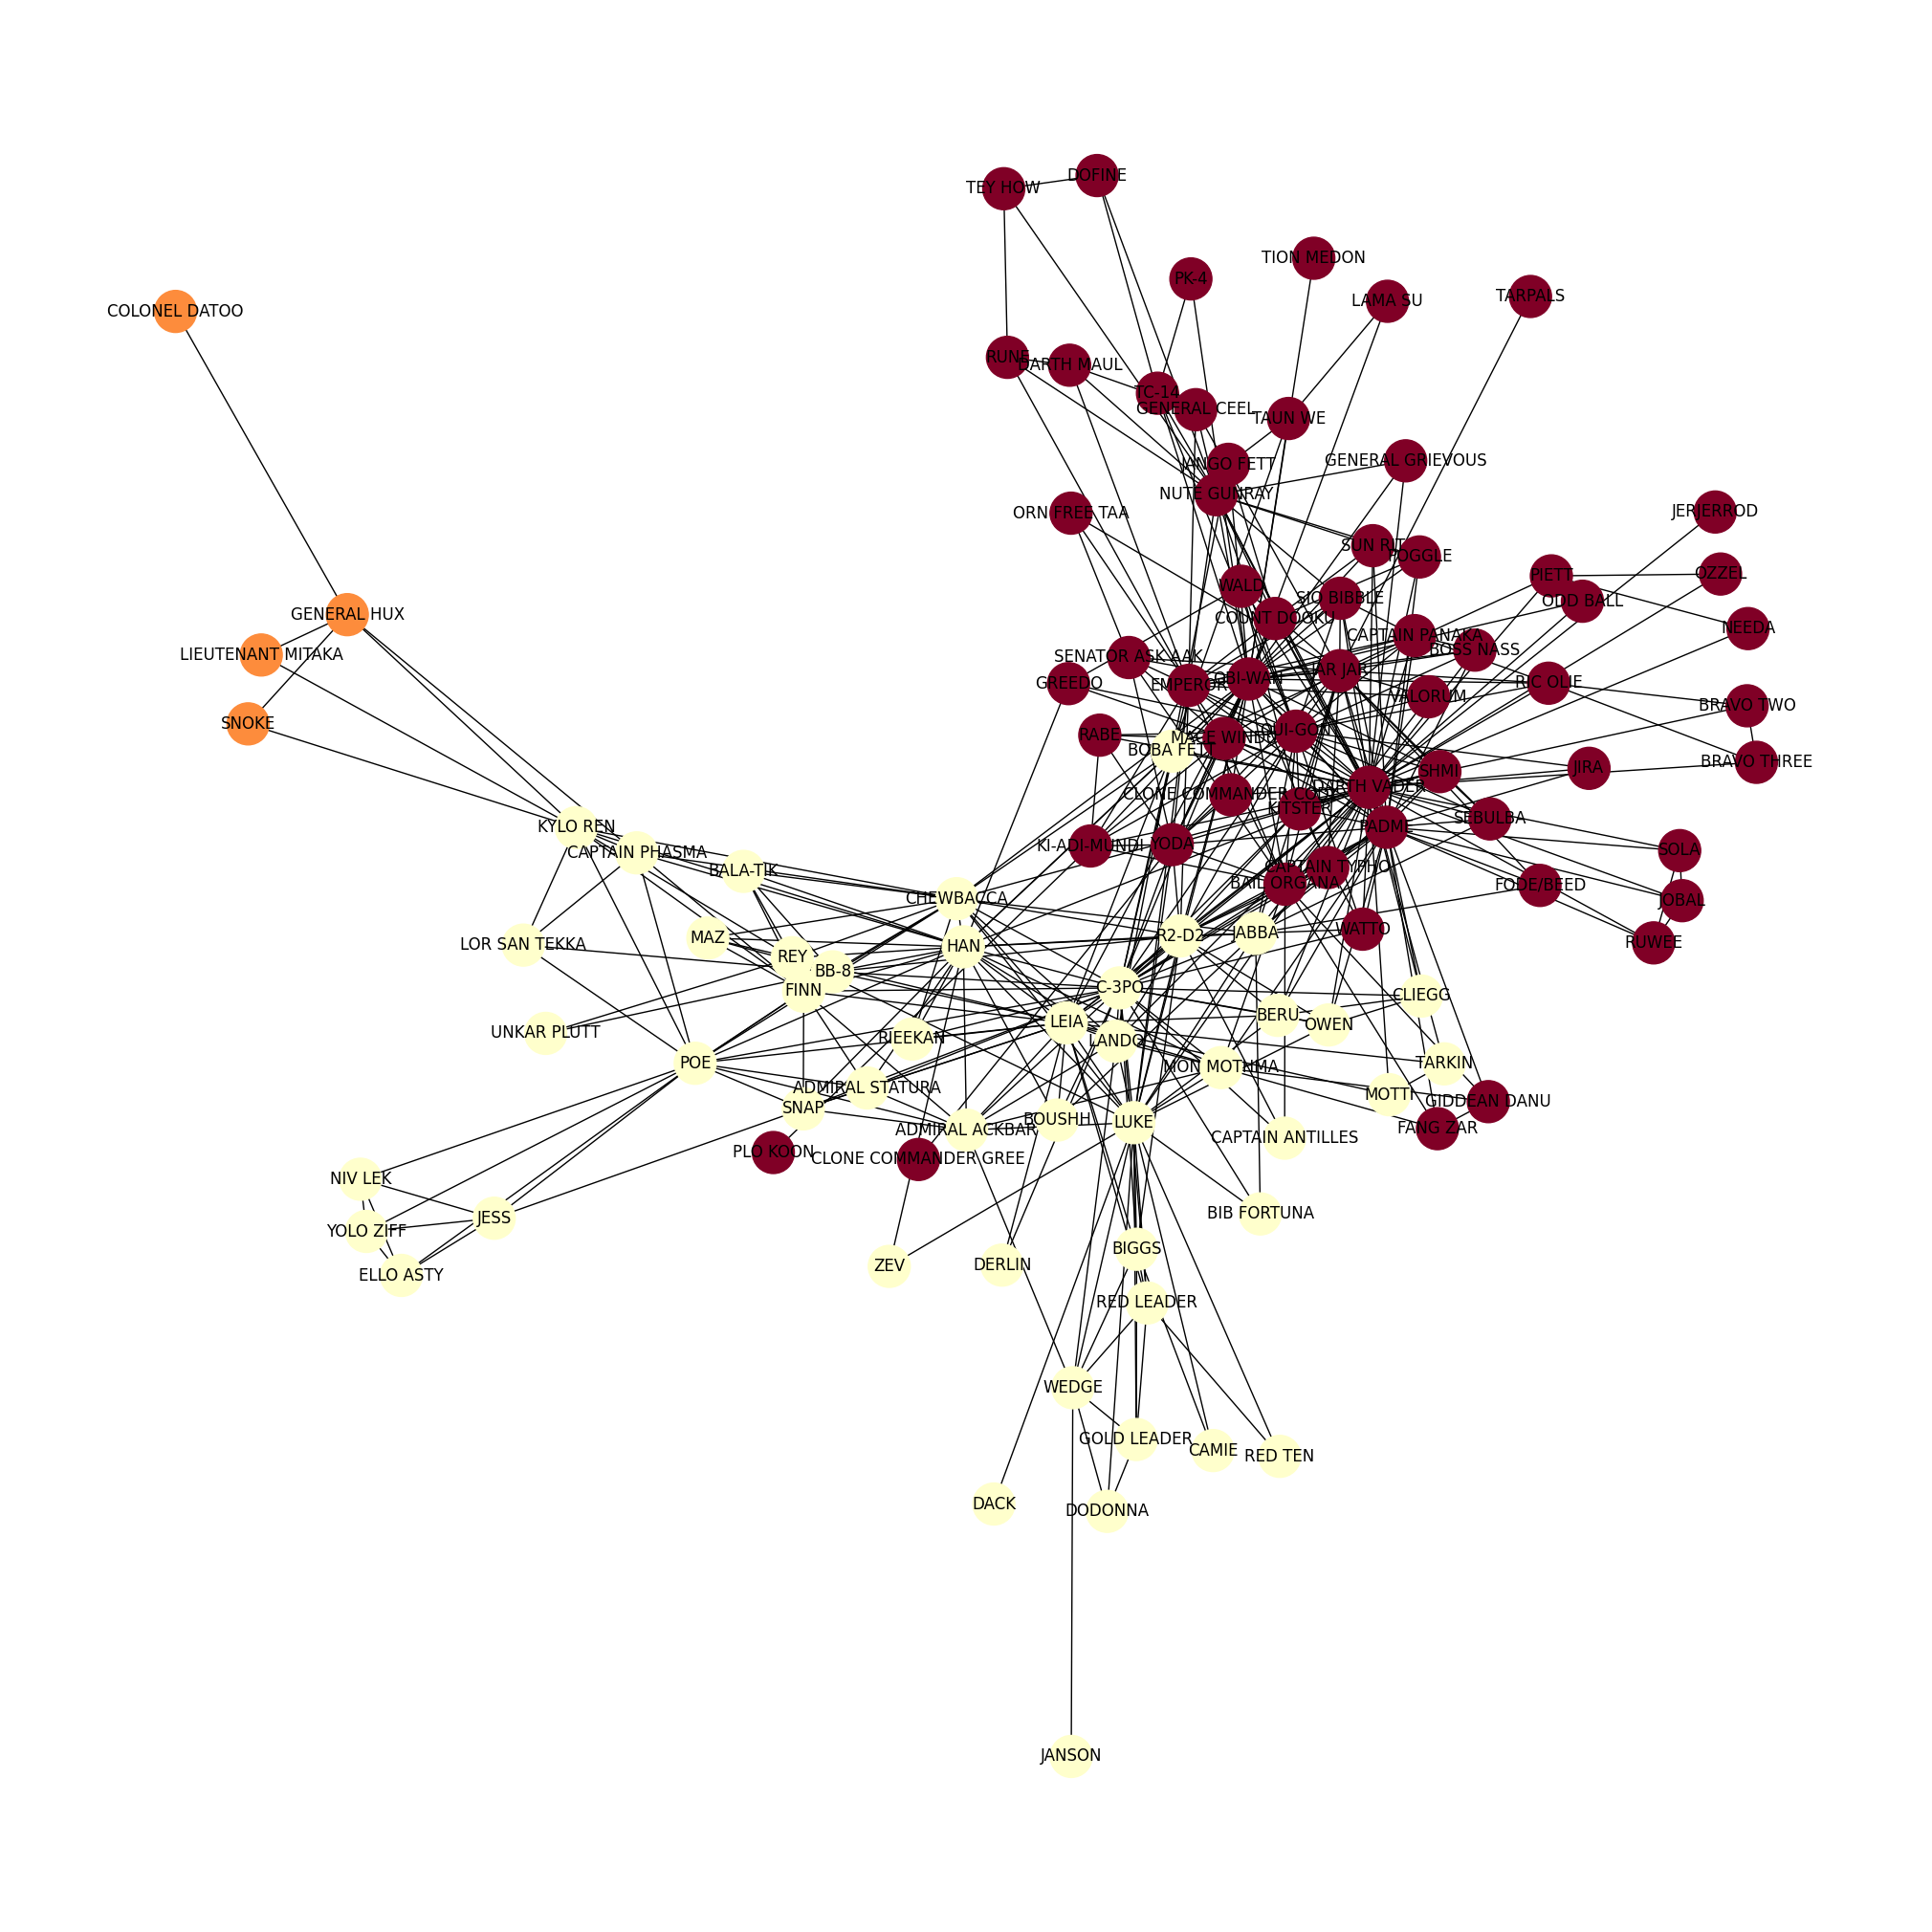

The best partition has modularity 0.3462 and 9 communities


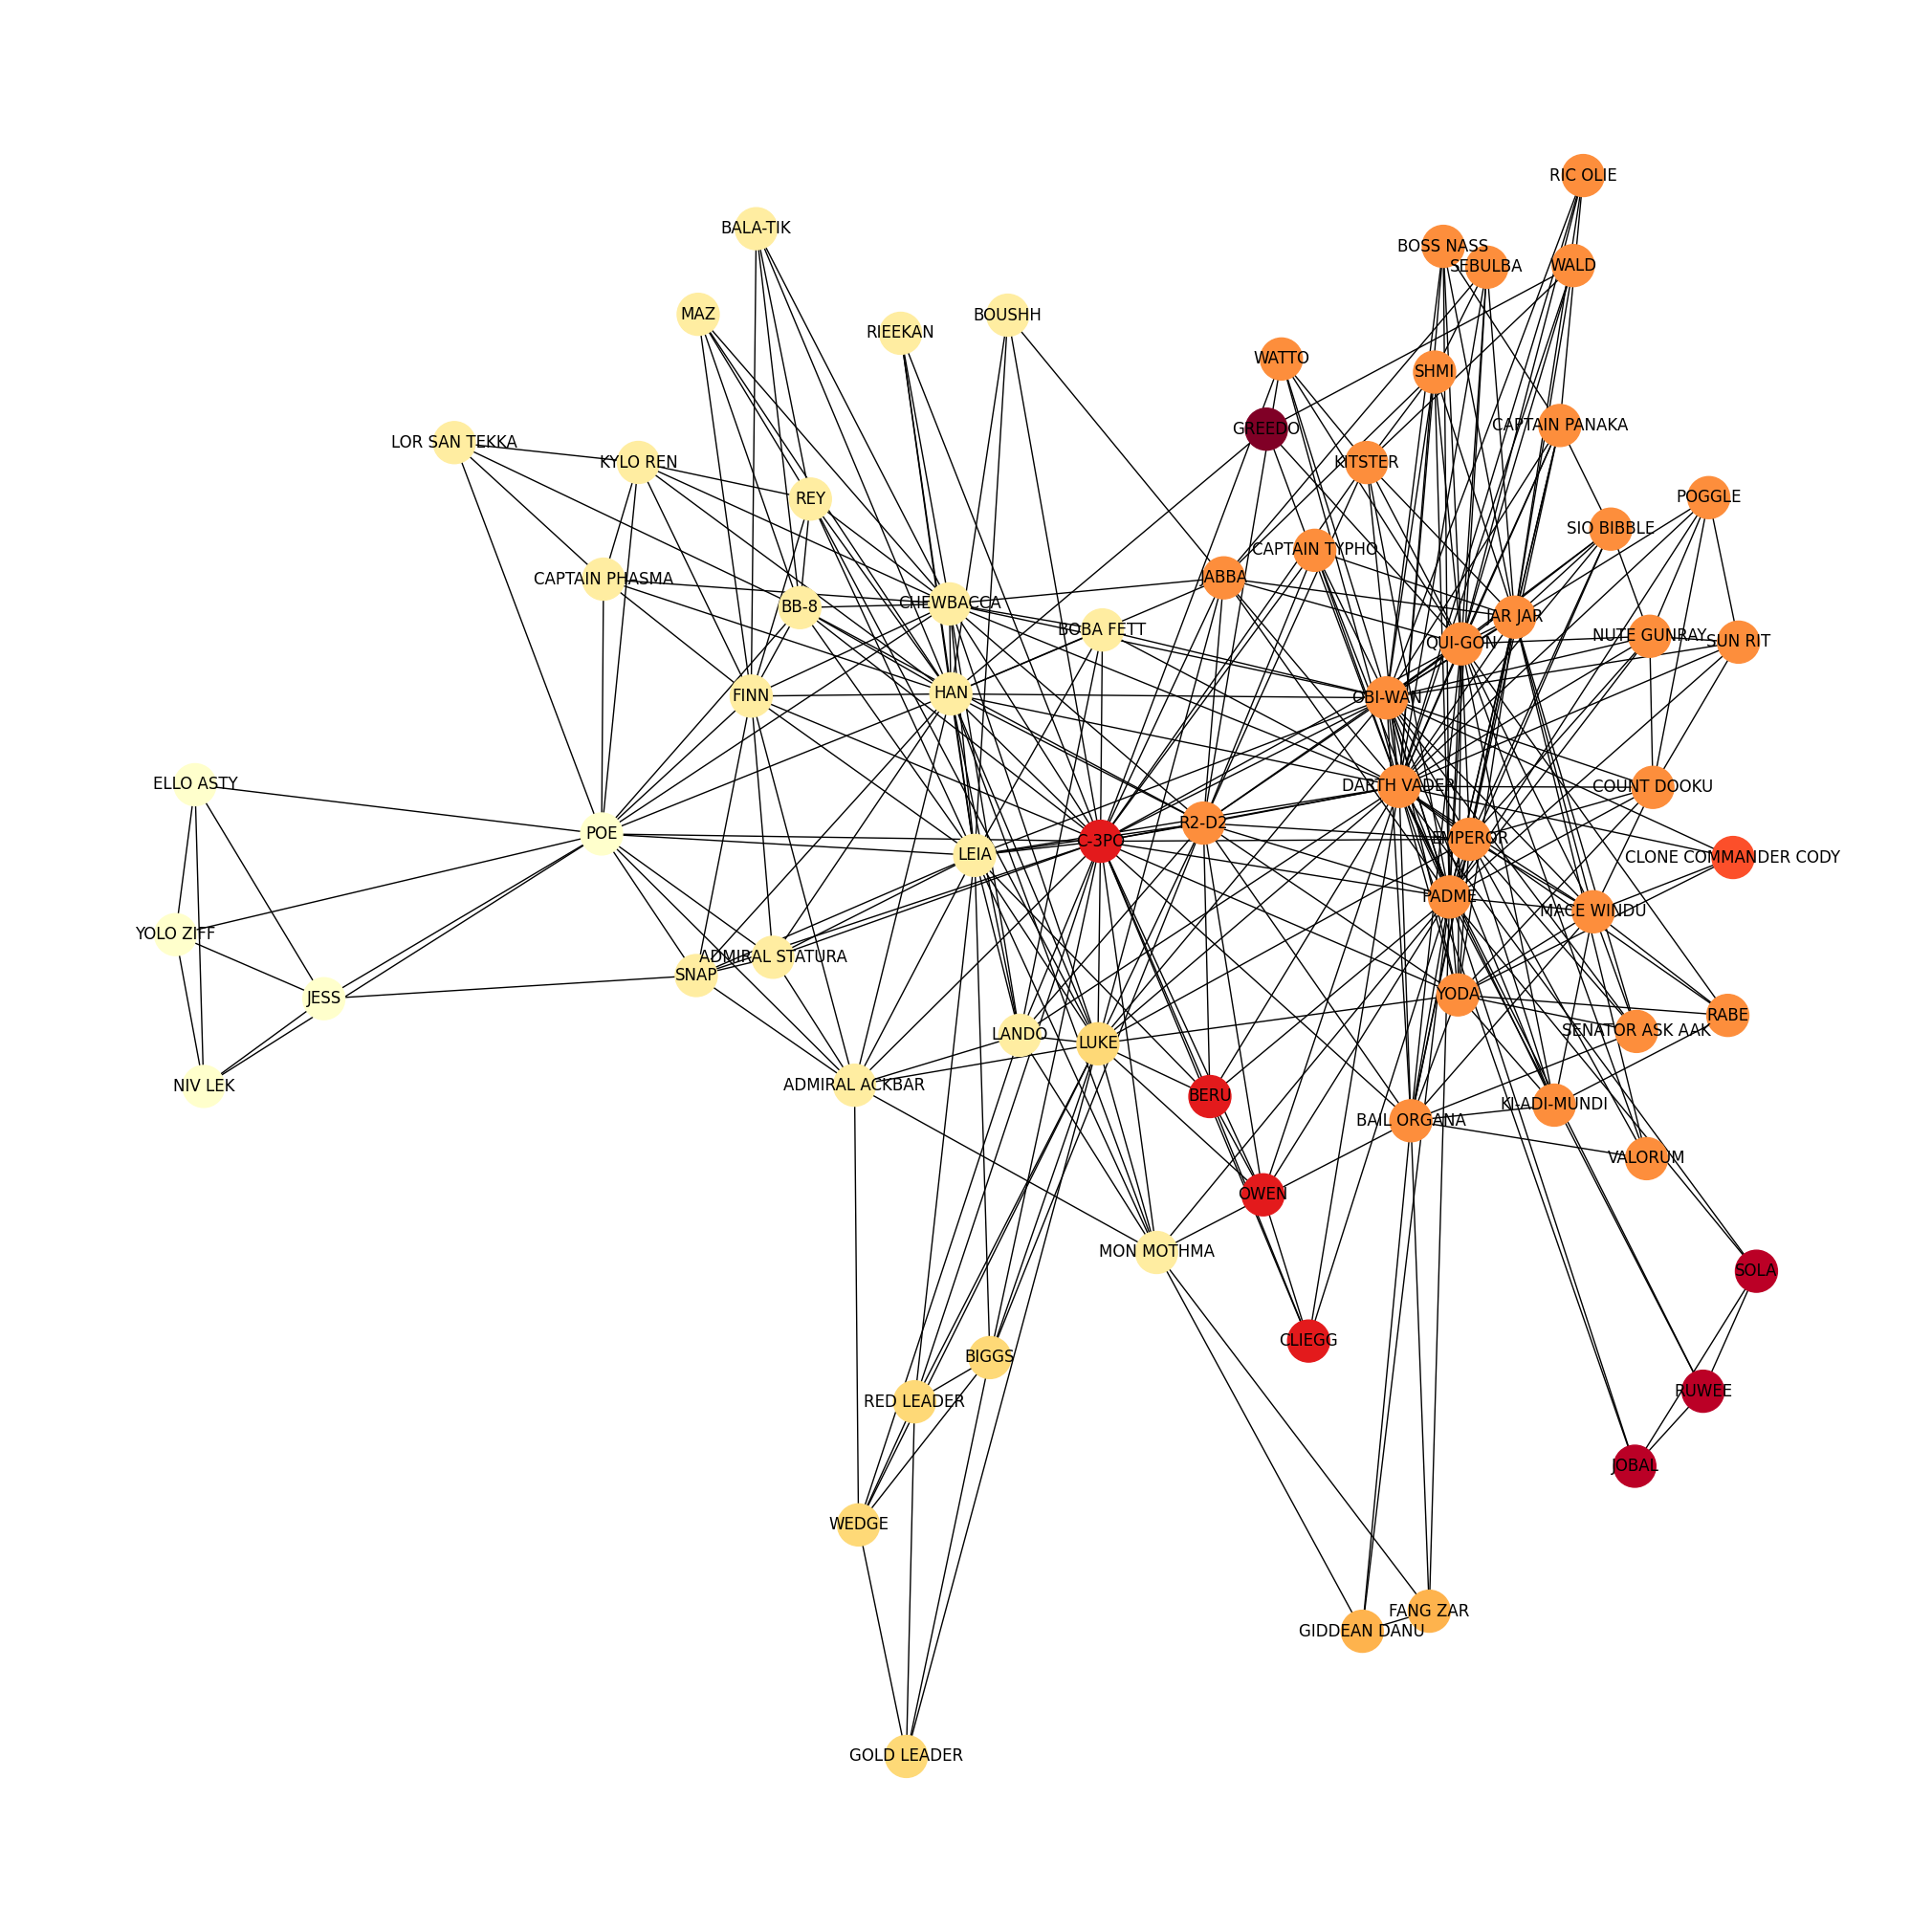

In [71]:
# LEAVE AS-IS

partition = run_girvan_newman_modularity(sw)
print("The best partition has modularity %.4f and %d communities" % (modularity(sw, partition), len(partition)))
plot_graph(sw, partition=partition)

partition = run_girvan_newman_modularity(swcore)
print("The best partition has modularity %.4f and %d communities" % (modularity(swcore, partition), len(partition)))
plot_graph(swcore, partition=partition)

<font size="+1" color="red">Replace this cell with a brief answer to the following questions regarding the COMPLETE GRAPH (sw)

How are the different communites connected between them? Why?  
You can look online to check if the characters in those communities are somehow related in the series. </font>

# Deliver your code (individually)

A .zip file containing:

* This notebook.
* dataset following original structure "data/starwars/starwars.graphml"

<font size="+2" color="#003300">I hereby declare that, except for the code provided by the course instructors, all of my code, report, and figures were produced by myself.</font>